# 2024-FOCUSED CROSS-SECTIONAL ANALYSIS OF INFLATION ACROSS COUNTRIES.

### INSTALLATIONS

In [58]:
!pip install country_converter

%pip install matplotlib seaborn plotly pandas numpy requests

Note: you may need to restart the kernel to use updated packages.


In [59]:
%pip install --upgrade kaleido

Note: you may need to restart the kernel to use updated packages.


In [50]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
from pathlib import Path

DATA_PATH = Path("dataset/inflation_cost_of_living_dataset.csv")

# 1. IMPORTATIONS

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests
from country_converter import CountryConverter
import textwrap

import warnings
warnings.filterwarnings("ignore")

In [53]:
import utility
from utility import demarcation, shorten_labels
from utility import PlotBuilder

builder = PlotBuilder()
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


# 2. DATA PREPARATION

In [65]:
#df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/inflation_cost_of_living_dataset.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,country,country_code_x,region,income_level,capital_city,latitude,longitude,country_code_y,inflation_year,inflation_annual_pct,cost_living_index,rent_index,groceries_index,restaurants_index,purchasing_power_index,bread_price_usd,transport_oneway_usd,transport_monthly_pass_usd,rent_monthly_usd,utilities_monthly_usd
0,Aruba,NaN,Latin America & Caribbean,High income,Oranjestad,12.51670,-70.0167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,NaN,"Middle East, North Africa, Afghanistan & Pakistan",Low income,Kabul,34.52280,69.1761,AFG,2024.0,-6.601186,38.2,8.2,36.8,36.9,48.5,0.88,1.05,12.8,85.0,20.0
2,Angola,NaN,Sub-Saharan Africa,Lower middle income,Luanda,-8.81155,13.2420,AGO,2024.0,28.240495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,NaN,Europe & Central Asia,Upper middle income,Tirane,41.33170,19.8172,ALB,2024.0,2.215874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Andorra,NaN,Europe & Central Asia,High income,Andorra la Vella,42.50750,1.5218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
demarcation()
print("Dataset shape is : ", df.shape)
demarcation()
print(df.isna().sum())
demarcation()
print(df.info())

------------------------------------------------------------
************************************************************
------------------------------------------------------------
Dataset shape is :  (217, 20)
------------------------------------------------------------
************************************************************
------------------------------------------------------------
country                         0
country_code_x                217
region                          0
income_level                    0
capital_city                    6
latitude                        6
longitude                       6
country_code_y                 38
inflation_year                 38
inflation_annual_pct           38
cost_living_index             172
rent_index                    172
groceries_index               172
restaurants_index             172
purchasing_power_index        172
bread_price_usd               181
transport_oneway_usd          189
transport_monthly_pass_usd

In [ ]:
demarcation()
print(df.isna().sum())
demarcation()
print(df.isna().sum()/len(df) *100)
demarcation()

------------------------------------------------------------
************************************************************
------------------------------------------------------------
country                         0
country_code_x                217
region                          0
income_level                    0
capital_city                    6
latitude                        6
longitude                       6
country_code_y                 38
inflation_year                 38
inflation_annual_pct           38
cost_living_index             172
rent_index                    172
groceries_index               172
restaurants_index             172
purchasing_power_index        172
bread_price_usd               181
transport_oneway_usd          189
transport_monthly_pass_usd    189
rent_monthly_usd              178
utilities_monthly_usd         192
dtype: int64
------------------------------------------------------------
************************************************************
--

In [ ]:
#Drop columns with greater than 50% missing values
null_pct = df.isna().sum()/len(df) *100
# null_pct.index
drop_cols = [col for col in null_pct.index if null_pct[col] > 50]
drop_cols
demarcation()

------------------------------------------------------------
************************************************************
------------------------------------------------------------


In [ ]:
df_data = df.drop(columns=drop_cols)
demarcation()
print(df_data.info())
demarcation()

------------------------------------------------------------
************************************************************
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               217 non-null    str    
 1   region                217 non-null    str    
 2   income_level          217 non-null    str    
 3   capital_city          211 non-null    str    
 4   latitude              211 non-null    float64
 5   longitude             211 non-null    float64
 6   country_code_y        179 non-null    str    
 7   inflation_year        179 non-null    float64
 8   inflation_annual_pct  179 non-null    float64
dtypes: float64(4), str(5)
memory usage: 15.4 KB
None
------------------------------------------------------------
************************************************

In [ ]:
cc = CountryConverter()
df_data['IS03_country'] = cc.convert(df_data['country'], to="iso3")
df_data.head()

Channel Islands not found in regex
Naoero not found in regex


,country,region,income_level,capital_city,latitude,longitude,country_code_y,inflation_year,inflation_annual_pct,IS03_country
0,Aruba,Latin America & Caribbean,High income,Oranjestad,12.51670,-70.0167,NaN,NaN,NaN,ABW
1,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,Kabul,34.52280,69.1761,AFG,2024.0,-6.601186,AFG
2,Angola,Sub-Saharan Africa,Lower middle income,Luanda,-8.81155,13.2420,AGO,2024.0,28.240495,AGO
3,Albania,Europe & Central Asia,Upper middle income,Tirane,41.33170,19.8172,ALB,2024.0,2.215874,ALB
4,Andorra,Europe & Central Asia,High income,Andorra la Vella,42.50750,1.5218,NaN,NaN,NaN,AND


In [ ]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               217 non-null    str    
 1   region                217 non-null    str    
 2   income_level          217 non-null    str    
 3   capital_city          211 non-null    str    
 4   latitude              211 non-null    float64
 5   longitude             211 non-null    float64
 6   country_code_y        179 non-null    str    
 7   inflation_year        179 non-null    float64
 8   inflation_annual_pct  179 non-null    float64
 9   IS03_country          217 non-null    str    
dtypes: float64(4), str(6)
memory usage: 17.1 KB


In [ ]:
#Clean inflation year column
years = df_data['inflation_year'].astype(str)
corr_year = [year.split(".")[0] if type(year) != float else year for year in years]
df_data['inflation_year'] = corr_year
df_data['inflation_year'] = df_data['inflation_year']
df_data.head()

,country,region,income_level,capital_city,latitude,longitude,country_code_y,inflation_year,inflation_annual_pct,IS03_country
0,Aruba,Latin America & Caribbean,High income,Oranjestad,12.51670,-70.0167,NaN,NaN,NaN,ABW
1,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,Kabul,34.52280,69.1761,AFG,2024,-6.601186,AFG
2,Angola,Sub-Saharan Africa,Lower middle income,Luanda,-8.81155,13.2420,AGO,2024,28.240495,AGO
3,Albania,Europe & Central Asia,Upper middle income,Tirane,41.33170,19.8172,ALB,2024,2.215874,ALB
4,Andorra,Europe & Central Asia,High income,Andorra la Vella,42.50750,1.5218,NaN,NaN,NaN,AND


In [ ]:
demarcation()
print("")
print("Unique regions in dataset")
print("")
print(df_data['region'].unique())
demarcation()
df_data['region'].value_counts()

------------------------------------------------------------
************************************************************
------------------------------------------------------------

Unique regions in dataset

<StringArray>
[                       'Latin America & Caribbean ',
 'Middle East, North Africa, Afghanistan & Pakistan',
                               'Sub-Saharan Africa ',
                             'Europe & Central Asia',
                               'East Asia & Pacific',
                                        'South Asia',
                                     'North America']
Length: 7, dtype: str
------------------------------------------------------------
************************************************************
------------------------------------------------------------


region
Europe & Central Asia                                58
Sub-Saharan Africa                                   48
Latin America & Caribbean                            42
East Asia & Pacific                                  37
Middle East, North Africa, Afghanistan & Pakistan    23
South Asia                                            6
North America                                         3
Name: count, dtype: int64

# 3. EXPLORATORY DATA ANALYSIS

## 3.1 Distribution of Annual Inflation 

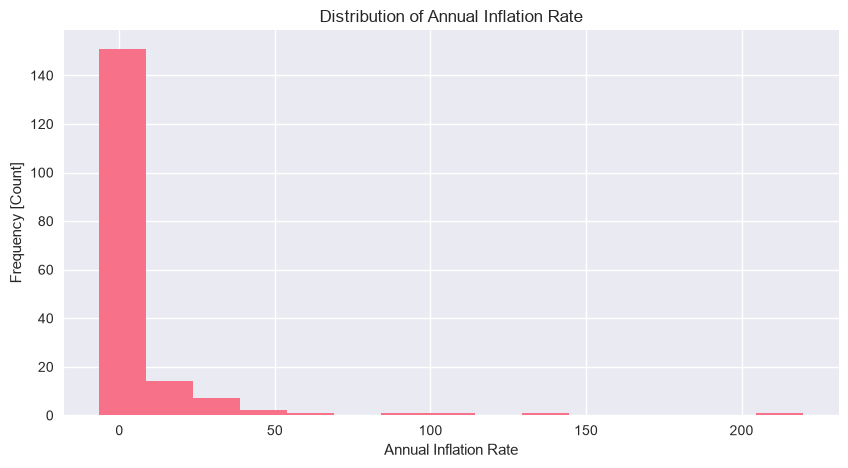

In [ ]:
fig = builder.pandas_hist(data=df_data['inflation_annual_pct'],
                     x_label="Annual Inflation Rate",
                     y_label="Frequency [Count]",
                     fig_size=(10,5),
                     title="Distribution of Annual Inflation Rate")
#fig.savefig("images/hist_annual_inflation_rate.png", dpi=300, bbox_inches="tight")

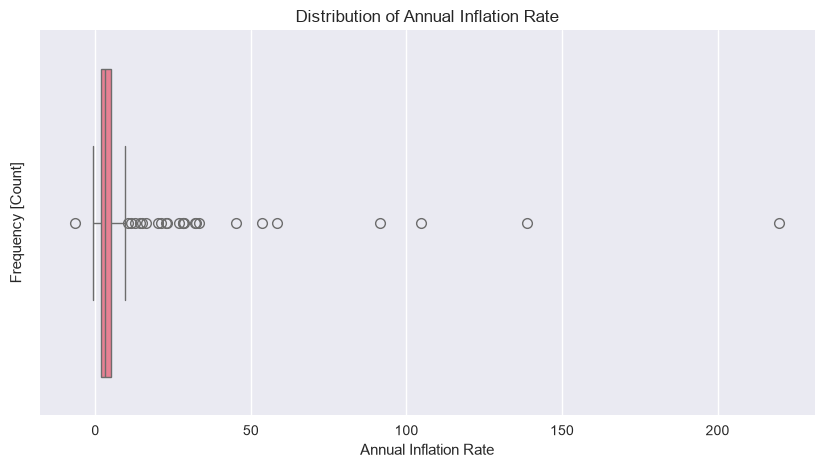

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x=df_data['inflation_annual_pct'], ax=ax)
plt.xlabel("Annual Inflation Rate")
plt.ylabel("Frequency [Count]")
plt.title("Distribution of Annual Inflation Rate")
plt.show()
#fig.savefig("images/boxplot_annual_inflation.png", dpi=300, bbox_inches="tight")

## 3.2 Distribution of Inflation Years 

------------------------------------------------------------
************************************************************
------------------------------------------------------------
Inflation Year Distribtion

inflation_year
2024    174
2022      3
2023      2
Name: count, dtype: int64
------------------------------------------------------------
************************************************************
------------------------------------------------------------


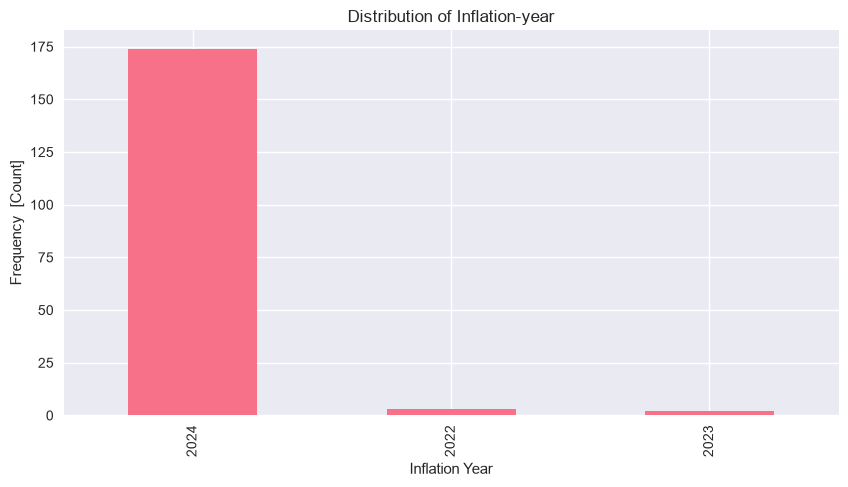

In [ ]:
demarcation()
print("Inflation Year Distribtion")
print("")
print(df_data['inflation_year'].value_counts())
demarcation()

fig, ax = plt.subplots(figsize=(10,5))
df_data['inflation_year'].value_counts().plot(kind = "bar", ax=ax)
plt.xlabel("Inflation Year")
plt.ylabel("Frequency  [Count]")
plt.title("Distribution of Inflation-year")
plt.show()
#fig.savefig("images/distr_inflation_year.png", dpi=300, bbox_inches="tight")

## 3.3 Distribution of Countries per Region

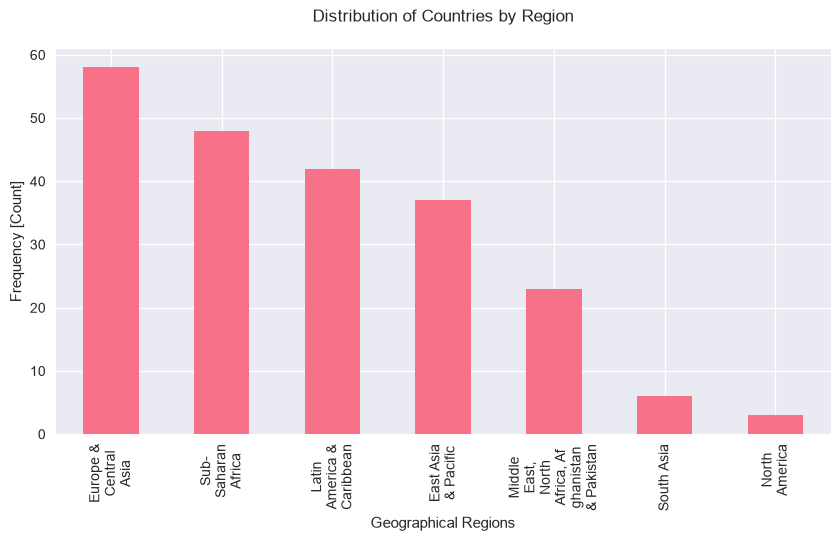

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
#sns.countplot(data=df_data, x="region", axes=ax)
df_data['region'].value_counts().plot(kind="bar", ax=ax)
plt.xticks(rotation = 90)
plt.xlabel("Geographical Regions")
plt.ylabel("Frequency [Count]")
utility.shorten_labels(axis=ax)
plt.title("Distribution of Countries by Region", y=1.05)
plt.show()
#fig.savefig("images/distr_countries.png", dpi=300, bbox_inches="tight")

In [ ]:
income_inflation = df_data.groupby("income_level")["inflation_annual_pct"].mean().sort_values()
income_inflation

income_level
High income             2.423697
Upper middle income     8.780368
Lower middle income    12.354631
Low income             20.678132
Name: inflation_annual_pct, dtype: float64

## 3.4 Annual Inflation by Income Level of Countries

In [ ]:
fig = px.bar(
    data_frame = income_inflation,
    x = income_inflation.index,
    y = income_inflation.values,
    color = income_inflation.values,
    color_continuous_scale= px.colors.sequential.Blues,
    title = "Annual-Inflation Rate Categorized by Income Level of Contries")
fig.update_layout(
    xaxis_title = "Income Level",
    yaxis_title = "Annual Inflation Rate"
)
fig.show()
#fig.write_image("images/inflation_income_level.png", width=1600, height=900, scale=2)

## 3.5 Countries by Region per Income Level

In [ ]:
df_data.groupby(["income_level", "region"])["country"].size()


income_level         region                                           
High income          East Asia & Pacific                                  15
                     Europe & Central Asia                                40
                     Latin America & Caribbean                            19
                     Middle East, North Africa, Afghanistan & Pakistan     8
                     North America                                         3
                     Sub-Saharan Africa                                    1
Low income           East Asia & Pacific                                   1
                     Middle East, North Africa, Afghanistan & Pakistan     3
                     Sub-Saharan Africa                                   21
Lower middle income  East Asia & Pacific                                   8
                     Europe & Central Asia                                 3
                     Latin America & Caribbean                             5
     

In [ ]:
mask = df_data['income_level'] == "Low income"
mask_b = df_data['income_level'] == "Lower middle income"
mask_c = df_data['income_level'] == "Upper middle income"
mask_d = df_data['income_level'] == "High income"

low_income = df_data[mask]
lower_middle_income = df_data[mask_b]
upper_middle_income = df_data[mask_c]
high_income = df_data[mask_d]

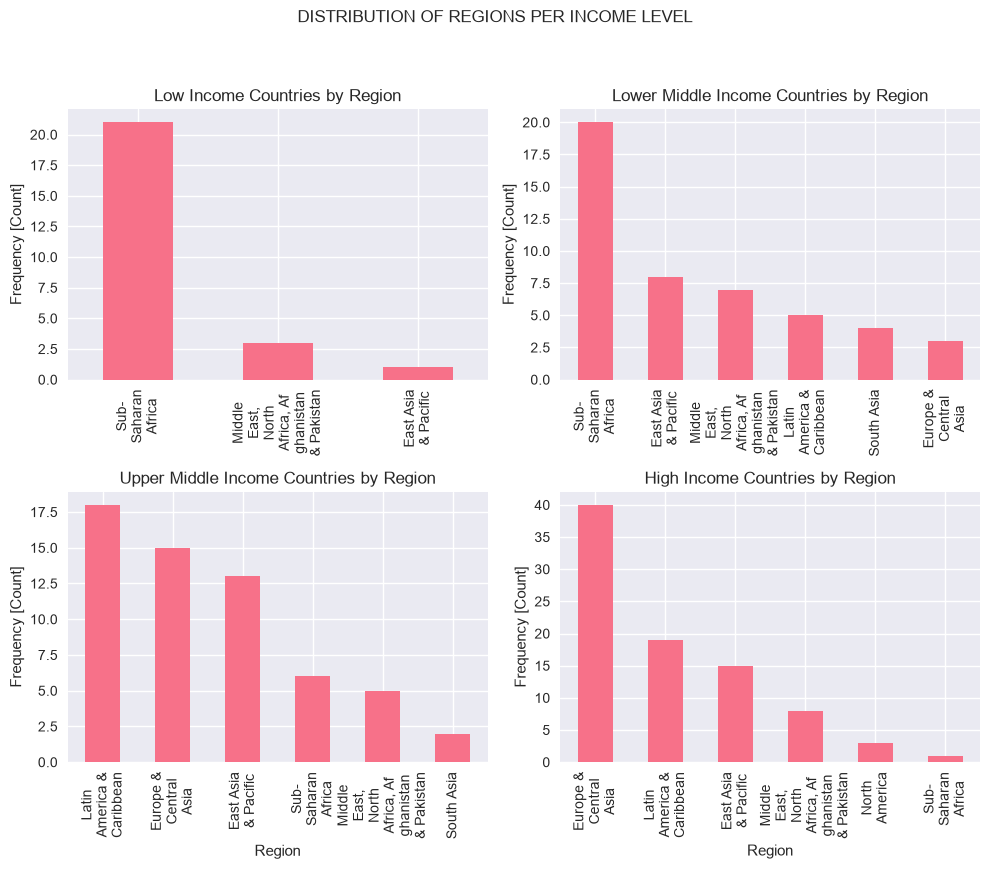

In [ ]:

params = {
    "plot_1": {
    "plot_type": "pandas_bar",
    "d_frame":low_income["region"].value_counts(),
    "x_col":None,
    "x_label": "",
    "y_label": "Frequency [Count]",
    "y_col":None,
    "title":"Low Income Countries by Region",
    "axis": [0,0]
},

    "plot_2": {
    "plot_type": "pandas_bar",
    "d_frame":lower_middle_income["region"].value_counts(),
    "x_col":None,
    "x_label": "",
    "y_label": "Frequency [Count]",
    "y_col":None,
    "title":"Lower Middle Income Countries by Region",
    "axis": [0,1]
},

    "plot_3": {
    "plot_type": "pandas_bar",
    "d_frame":upper_middle_income["region"].value_counts(),
    "x_col":None,
    "x_label": "Region",
    "y_label": "Frequency [Count]",
    "y_col":None,
    "title":"Upper Middle Income Countries by Region",
    "axis": [1,0]
},
    "plot_4": {
    "plot_type": "pandas_bar",
    "d_frame": high_income["region"].value_counts(),
    "x_col":None,
    "x_label": "Region",
    "y_label": "Frequency [Count]",
    "y_col":None,
    "title":"High Income Countries by Region",
    "axis": [1,1]
}
}
fig = builder.multiple_plots(grid=(2,2), fig_size=(10,8), plots=params, sup_title="DISTRIBUTION OF REGIONS PER INCOME LEVEL")
fig.show()
#fig.savefig("images/multi_plot_income.png", dpi=300, bbox_inches="tight")

In [ ]:
#Check Sub-Saharan High Income Country
high_income["region"] = (
    high_income["region"]
    .astype(str)
    .str.strip()
)

df_data["region"] = df_data["region"].str.strip()

maska = high_income['region'] ==  "Sub-Saharan Africa"
high_income[maska]

,country,region,income_level,capital_city,latitude,longitude,country_code_y,inflation_year,inflation_annual_pct,IS03_country
185,Seychelles,Sub-Saharan Africa,High income,Victoria,-4.6309,55.4466,SYC,2024,0.311726,SYC


### From this, we see that Sychelles is the only high income country in Sub-Saharan Africa

## 3.6 Inflation by Region

In [ ]:
#categorize inflation by region
region_inflation = df_data.groupby("region")["inflation_annual_pct"].mean().sort_values()
region_inflation

region
North America                                         2.665555
East Asia & Pacific                                   3.134317
South Asia                                            3.974462
Europe & Central Asia                                 4.425715
Middle East, North Africa, Afghanistan & Pakistan     9.527164
Latin America & Caribbean                            11.208234
Sub-Saharan Africa                                   15.535423
Name: inflation_annual_pct, dtype: float64

In [ ]:
fig = px.bar(
    data_frame = region_inflation,
    x = region_inflation.index,
    y = region_inflation.values,
    color = region_inflation.values,
    color_continuous_scale= px.colors.sequential.Reds,
    title = "Annual Inflation Rate by Region"
)
fig.update_layout(
    xaxis_title = "Region",
    yaxis_title = "Annual Inflation Rate"
)
fig.show()

#fig.write_image("images/annual_inflation_rate_by_region.png", width=1600, height=900, scale=2)

## 3.7  Geographic Distribution

In [ ]:
fig = px.choropleth(
    data_frame = df_data,
    locations = "IS03_country",
    #projection = "orthographic",
    projection = "robinson",
    #projection = "equirectangular",
    color = "inflation_annual_pct",
    color_continuous_scale= px.colors.sequential.Reds,
    title = "Inflation By Country"
)

fig.show()
#fig.write_image("images/choropleth.png", width=1600, height=900, scale=2)

## 3.8 Top 30 Countries with Inflation

In [ ]:
#filter out top 30 countries with inflation
top_30 = df_data.sort_values(by=["inflation_annual_pct"], ascending=False).head(30).reset_index().drop(columns="index")

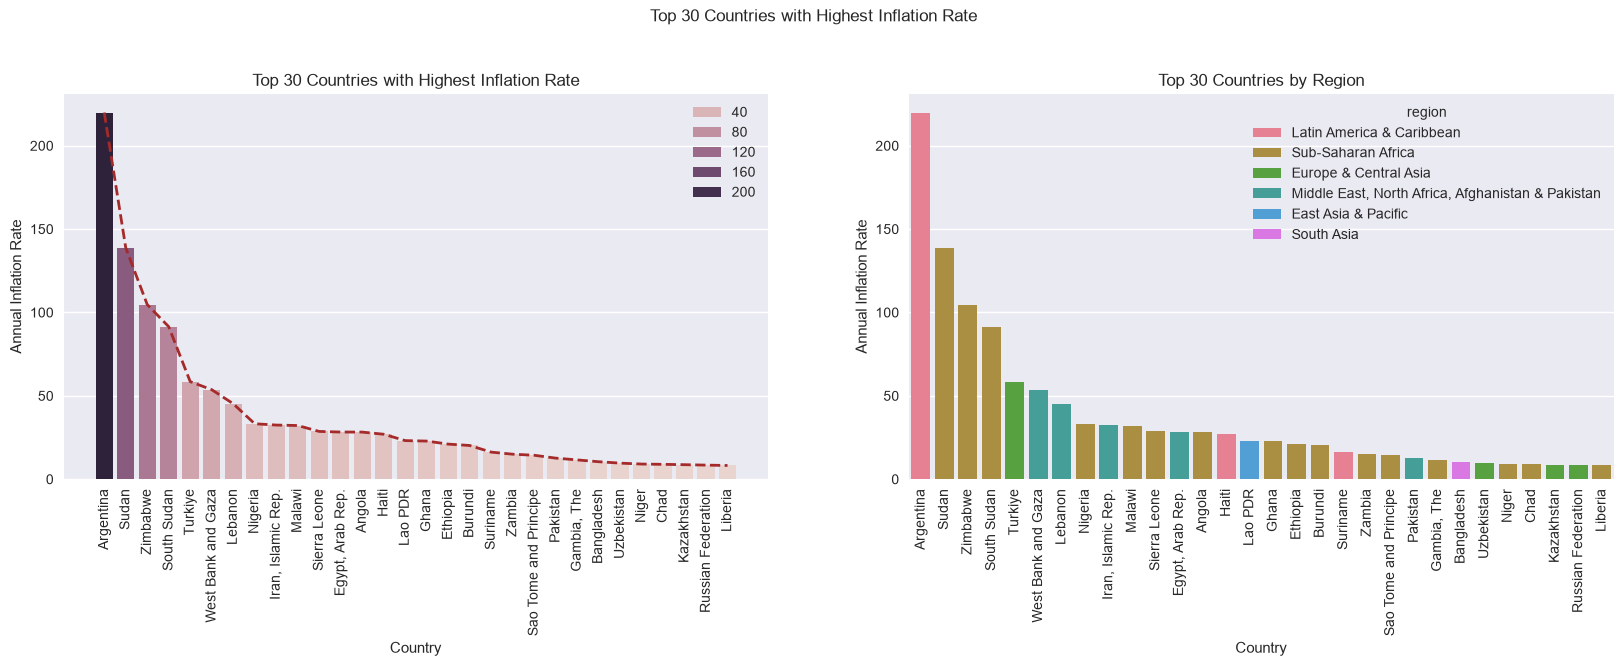

In [ ]:
fig,(ax,ax2) = plt.subplots(1, 2, figsize=(20,5))
sns.barplot(data=top_30, x="country", y="inflation_annual_pct", ax=ax, hue="inflation_annual_pct")
sns.lineplot(data=top_30, x="country", y="inflation_annual_pct", ax=ax, color="brown", linestyle="--", linewidth="2")
ax.set_xlabel("Country")
ax.set_ylabel("Annual Inflation Rate")
ax.tick_params(axis="x", rotation=90)
ax.set_title("Top 30 Countries with Highest Inflation Rate")

sns.barplot(data=top_30, x="country", y="inflation_annual_pct", ax=ax2, hue="region")
ax2.set_xlabel("Country")
ax2.set_ylabel("Annual Inflation Rate")
ax2.set_title("Top 30 Countries by Region")
ax2.tick_params(axis="x", rotation=90)

sns.despine()
fig.suptitle("Top 30 Countries with Highest Inflation Rate", y=1.05)
fig.show()

#fig.savefig("images/top_30_countries_inflation.png", dpi=300, bbox_inches="tight")

## Top 10 Countries with Inflation

In [ ]:
fig = px.bar(
    data_frame = top_30.head(10),
    x = "country",
    y = "inflation_annual_pct",
    color = "inflation_annual_pct",
    color_continuous_scale= px.colors.sequential.Reds,
    title = "Top 10 Countries with Highest Inflation Rate"
)
fig.update_layout(
    xaxis_title = "Country",
    yaxis_title = "Annual Inflation Rate"
)
fig.show()
#fig.write_image("images/top_10_countries_inflation.png", width=1600, height=900, scale=2)

# 4. FINDINGS

•  Low-income countries: 20.68% mean inflation 
•  Lower-middle income: 12.35% 
•  Upper-middle income: 8.78% 
•  High-income: 2.42%


Sub-Saharan Africa: 15.54% — highest
Latin America & Caribbean: 11.21%
MENA/AP: 9.53%
Europe & Central Asia: 4.43%
South Asia: 3.97%
East Asia & Pacific: 3.13%
North America: 2.67% — lowest

The top country was Argentina at 219.88%, followed by Sudan, Zimbabwe, and South Sudan.








# 5. CONCLUSION

The analysis shows substantial differences in inflation across both income groups and geographic regions.

High-income countries recorded the lowest average inflation, while low-income countries recorded the highest. Among geographic regions, Sub-Saharan Africa had the highest average inflation, while North America had the lowest.

At the country level, inflation was heavily concentrated among a small number of countries, with Argentina recording the highest value in the dataset at approximately 219.88%.

Overall, the project provides a useful descriptive snapshot of global inflation, particularly for 2024, but further statistical testing and multi-year data would be needed to establish stronger relationships, assess uncertainty, and investigate inflation trends over time.